In [1]:
import h5py
import scipy
import numpy as np
from tqdm import tqdm

In [2]:
def ROM(x,t, omega,A_F):
    u1, v1, u2, v2, u3, v3, u4, v4 = x
    dv1 = -1.839423e-01**2	*u1 + 2.038503e-06	*u1**2 - 3.756942e-11*u1**3 - 2.027974e-04*v1 - 1.271243e-04*v1**2 - 8.958187e-02/1.5*A_F*np.cos(omega*t)
    dv2 = -1.839351e-01**2	*u2 + 1.562781e-06*u2**2 - 9.452131e-11*u2**3 - 1.643286e-04*v2 + 2.861995e-05*v2**2 - 7.549999e-02/1.5*A_F*np.cos(omega*t)
    dv3 = -1.838850e-01**2 * u3 - 1.596755e-06	*u3**2 - 1.174480e-10*u3**3 - 2.069170e-04*v3 - 3.012409e-05*v3**2 - 8.765379e-02/1.5*A_F*np.cos(omega*t)
    dv4 = -1.839044e-01**2	*u4 - 2.061617e-06*u4**2 - 5.034116e-11*u4**3 - 1.815047e-04*v4 + 1.253700e-04*v4**2 - 	7.588136e-02/1.5*A_F*np.cos(omega*t)
    return [v1,dv1,v2,dv2,v3,dv3,v4,dv4]

In [5]:
datadir = r'C:\Users\Teng Ma\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_data_perseus_2025-05-16_1416\data_perseus'
datadir = r'D:\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_data_perseus_2025-05-16_1416\data_perseus'
POM = "%s/%s"%(datadir, 'POM.mat')

positionname = 'sindy_perseus_S_FRF_IC0.mat'
velocityname = 'sindy_perseus_S_vel_FRF_IC0.mat'
datafile = "%s/%s"%(datadir, positionname)
P = "%s/%s"%(datadir, 'sindy_perseus_I_FRF_IC0.mat')
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
with h5py.File(datafile, 'r') as file:
    data = np.array(file['S'])
with h5py.File(P, 'r') as file:
    p = np.array(file['I'])

OSError: [Errno 22] Unable to synchronously open file (file read failed: time = Sun Nov  2 11:00:41 2025
, filename = 'D:\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_data_perseus_2025-05-16_1416\data_perseus/sindy_perseus_S_FRF_IC0.mat', file descriptor = 3, errno = 22, error message = 'Invalid argument', buf = 0000006640FEA670, total read size = 8, bytes this sub-read = 8, bytes actually read = 18446744073709551615, offset = 0)

In [7]:
timestamp = 99999
timeeffect = 99999
Modeshape = scipy.io.loadmat(POM)["POM"]
node = 4184
num = int(len(p[2,:])/timestamp)
Omegas_FOM = np.zeros(num)
Amplitudes_FOM = np.zeros(num)
responses_FOM = np.zeros(num)
transformation_matrix = 1/np.sqrt(4)*np.array([[1,1,1,1],[1,-1,1,-1],[1,1,-1,-1],[1,-1,-1,1]])
POM_1 = np.zeros(4)
for i in range(4):
    # print(f[node,i])
    POM_1[i] = Modeshape[node,i]
rotation_matrix = np.dot(POM_1,transformation_matrix.T)
print(rotation_matrix)

[-0.00275492 -0.02829377  0.00880975 -0.01281896]


In [15]:
import scipy.io
a = scipy.io.loadmat('../Simulations/mirror_matcont.mat')['xlcc']
Omegas_ROM = a[-1]
stablestamp = len(a[:-12:10,0])
Modes = 4
orbit_ROM = np.zeros([len(Omegas_ROM),stablestamp,Modes])
for i in tqdm(range(len(Omegas_ROM))):
    for j in range(Modes):
        orbit_ROM[i,:,j] = a[0+j*2:-12+j*2:10,i]

100%|██████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 186587.66it/s]


In [20]:
response_ROM = np.zeros([len(Omegas_ROM)])
# fig,axes = plt.subplots( len(Afs_ROM),len(Omegas_ROM), figsize = (15,2), dpi = 300)
for i in tqdm(range(len(Omegas_ROM))):
    rotation_orbit = np.dot(rotation_matrix, orbit_ROM[i,:,:].T)
        # axes[j][i].plot(rotation_orbit/np.max(rotation_orbit),np.gradient(rotation_orbit)/np.max(np.gradient(rotation_orbit)), lw = 0.01)
        # if j == 0:
        #     axes[j][i].set_title(Omegas_ROM[i])
        # plt.plot(rotation_orbit)
    response_ROM[i] = (np.max(rotation_orbit) - np.min(rotation_orbit))/2

100%|██████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 132861.48it/s]


In [21]:
import pandas as pd
Omegas_FOMs = []
response_FOMs = []
betas = [1.0,1.5,2.0,2.5,3.0]
for i in range(len(betas)):
    file = "../../Validation/Micromirror2/beta%.1f.csv"%betas[i]
    data = pd.read_csv(file, header = None)
    Omegas_FOMs.append(data[0])
    response_FOMs.append(data[1])

In [22]:
import matplotlib.pyplot as plt

cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
mpl.rc('xtick', labelsize=4)
mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=6)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=6)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/MicroMirror"

C:\Users\TengMa\AppData\Local\Temp\ipykernel_5424\4211462163.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("tab10")


Text(0, 0.5, '$\\theta$(deg)')

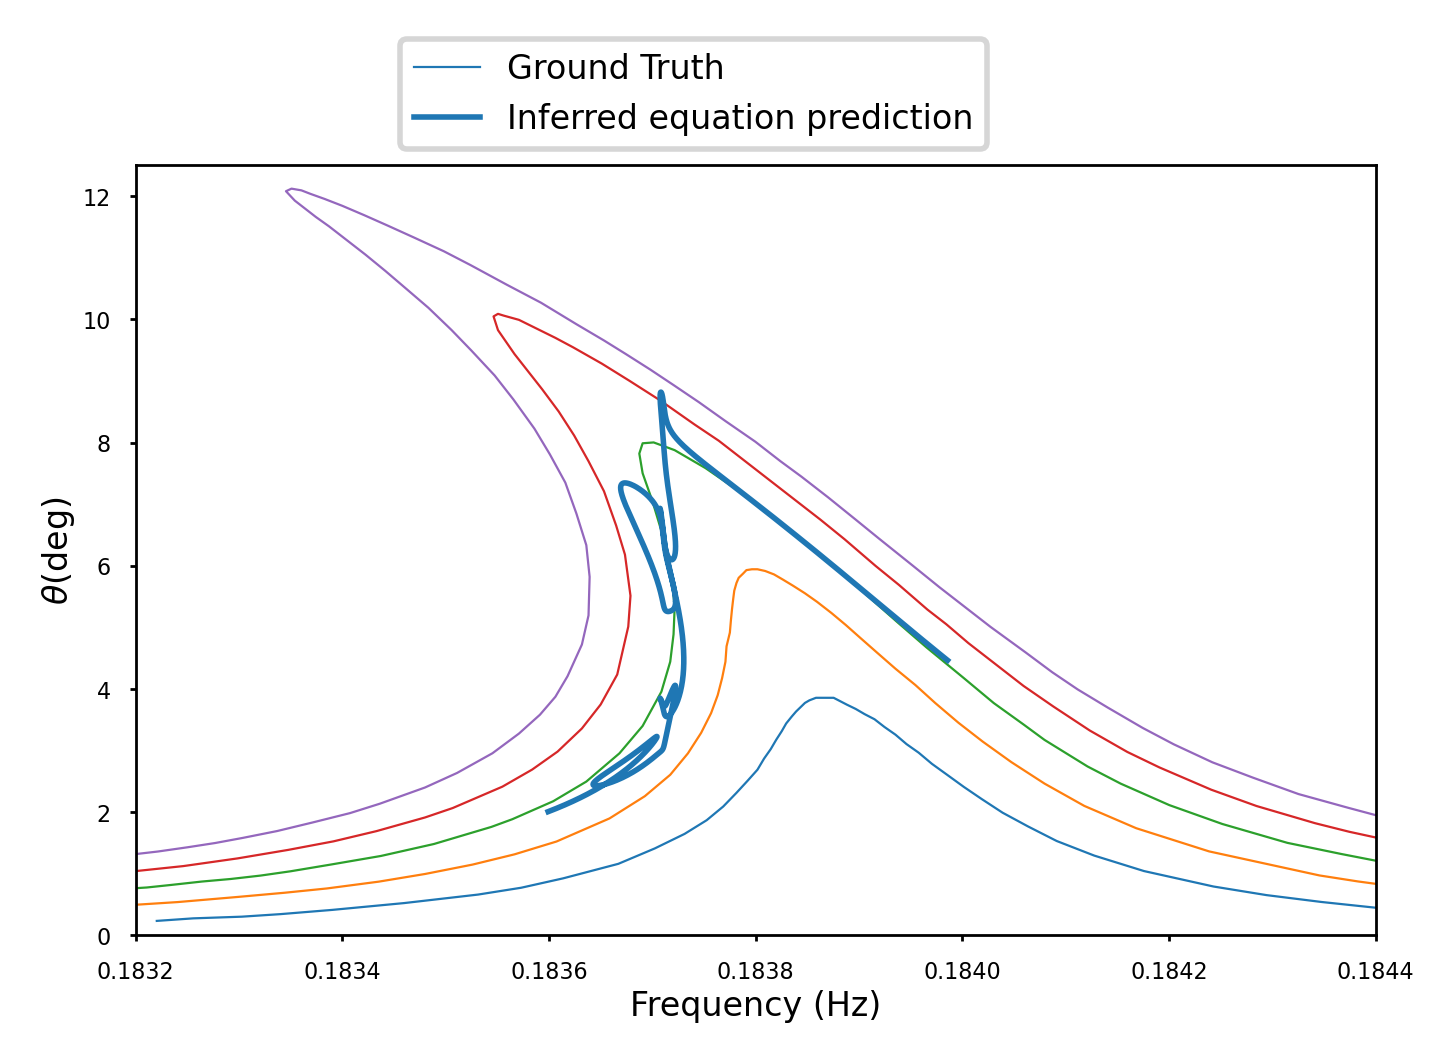

In [24]:
fig, ax = plt.subplots(figsize = (4,2.5),dpi = 400)
length = 400
# plt.scatter(Omegas_ROM,np.degrees(np.arcsin(response_ROM[1,:]/length)),s = 1)
# # plt.scatter(Omegas_ROM,np.degrees(np.arcsin(response_ROM_1[1,:]/length)),s = 1)
# plt.scatter(Omegas_ROM, np.degrees(np.arcsin(response_ROM[0,:]/length)),s = 1)
for i in range(len(betas)):
    if i == 0:
        
        plt.plot(Omegas_FOMs[i], response_FOMs[i], color = colors[i],lw = 0.4, label = 'Ground Truth')
        # plt.scatter(Omegas_ROM, np.degrees(np.arcsin(response_ROM[i]/length)),s = 1, color = colors[i], label = "Inferred equation prediction")
    else:
        plt.plot(Omegas_FOMs[i], response_FOMs[i], color = colors[i],lw = 0.4)
        # plt.scatter(Omegas_ROM, np.degrees(np.arcsin(response_ROM[i,:]/length)),s = 1, color = colors[i])
plt.plot(Omegas_ROM, np.degrees(np.arcsin(response_ROM/length)),lw = 1, color = colors[0], label = "Inferred equation prediction")
plt.legend(fontsize = 6, bbox_to_anchor = (0.2,1))
# plt.scatter(Omegas_FOM, responses_FOM, s =9,marker = '*',label = 'FOM',zorder = 100)
ax.set_ylim(0,12.5)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlim(0.1832,0.1844)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'$\theta$(deg)')